# EDA Изучаю dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

sns.set_style(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("used_cars.csv")

df_dev_raw, df_test_raw = train_test_split(
    df,
    test_size=0.2,
    random_state=21
)

df_dev_raw = df_dev_raw.copy()
df_test_raw = df_test_raw.copy()


In [2]:
df_dev_raw.shape


(3207, 12)

In [3]:
for clmn in df_dev_raw.columns.tolist():
    print(clmn)


brand
model
model_year
milage
fuel_type
engine
transmission
ext_col
int_col
accident
clean_title
price


In [4]:
df_dev_raw.info()


<class 'pandas.DataFrame'>
Index: 3207 entries, 12 to 3017
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         3207 non-null   str  
 1   model         3207 non-null   str  
 2   model_year    3207 non-null   int64
 3   milage        3207 non-null   str  
 4   fuel_type     3073 non-null   str  
 5   engine        3207 non-null   str  
 6   transmission  3207 non-null   str  
 7   ext_col       3207 non-null   str  
 8   int_col       3207 non-null   str  
 9   accident      3118 non-null   str  
 10  clean_title   2725 non-null   str  
 11  price         3207 non-null   str  
dtypes: int64(1), str(11)
memory usage: 325.7 KB


In [5]:
df_dev_raw.head()


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
12,Toyota,Supra 3.0 Premium,2021,"12,500 mi.",Gasoline,382.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,A/T,Yellow,Black,None reported,Yes,"$53,500"
2812,Volkswagen,Golf GTI 2.0T SE 4-Door,2016,"90,000 mi.",Gasoline,210.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Gray,Black,None reported,Yes,"$16,750"
3273,RAM,1500 Rebel,2018,"54,800 mi.",Gasoline,395.0HP 5.7L 8 Cylinder Engine Gasoline Fuel,A/T,White,Black,At least 1 accident or damage reported,Yes,"$37,050"
1678,INFINITI,QX60 Base,2014,"154,247 mi.",Gasoline,265.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Black,At least 1 accident or damage reported,Yes,"$12,500"
1866,Audi,Q8 55 Premium Plus,2021,"30,000 mi.",Hybrid,335.0HP 3.0L V6 Cylinder Engine Gasoline/Mild ...,8-Speed A/T,Black,Black,None reported,Yes,"$62,000"


In [6]:
df_dev_raw.isnull().sum()


brand             0
model             0
model_year        0
milage            0
fuel_type       134
engine            0
transmission      0
ext_col           0
int_col           0
accident         89
clean_title     482
price             0
dtype: int64

In [7]:
for clmn in df_dev_raw.columns.tolist():
    print(f"{clmn}: {df_dev_raw[clmn].nunique()}")


brand: 55
model: 1674
model_year: 34
milage: 2335
fuel_type: 7
engine: 1046
transmission: 57
ext_col: 290
int_col: 138
accident: 2
clean_title: 1
price: 1365


In [8]:
df_dev_raw[df_dev_raw['fuel_type'].isnull()]['engine'].unique()


<StringArray>
[      '271.0HP Electric Motor Electric Fuel System',
       '691.0HP Electric Motor Electric Fuel System',
       '480.0HP Electric Motor Electric Fuel System',
       '355.0HP Electric Motor Electric Fuel System',
       '557.0HP Electric Motor Electric Fuel System',
       '425.0HP Electric Motor Electric Fuel System',
       '329.0HP Electric Motor Electric Fuel System',
       '835.0HP Electric Motor Electric Fuel System',
       '536.0HP Electric Motor Electric Fuel System',
       '616.0HP Electric Motor Electric Fuel System',
       '518.0HP Electric Motor Electric Fuel System',
                                          'Electric',
                             'Dual Motor - Standard',
       '402.0HP Electric Motor Electric Fuel System',
       '670.0HP Electric Motor Electric Fuel System',
      '1020.0HP Electric Motor Electric Fuel System',
               'Electric Motor Electric Fuel System',
       '620.0HP Electric Motor Electric Fuel System',
              

# Выводы на данный момент:
1) Все выводы EDA ниже делаю только по обучающей части данных. Тестовая выборка уже отделена и до финального запуска модели не используется.
2) Пропуски в `fuel_type`, судя по содержимому `engine`, в основном относятся к электрическим автомобилям, поэтому заполняю их значением `Electric`.
3) Пропуски в `accident` и `clean_title` заменяю отдельными значениями, чтобы не удалять строки и сохранить сам факт отсутствия информации.
4) Цена и пробег записаны строками, поэтому перевожу их в числовой тип. Цену перевожу в рубли, пробег — в километры, просто для удобства восприятия.
5) Из признака двигателя можно достаточно хорошо извлечь мощность и объем двигателя: покрытие получилось около 80% и 95% соответственно. Количество цилиндров заполнено только примерно у трети машин, поэтому его использовать не буду.
6) У цветов интерьера и экстерьера, модели и полного описания двигателя очень много категорий. Для OneHotEncoding это сильно увеличит размерность, поэтому дальше эти признаки уберу.


# EDA Заполнение пропусков, работа с признаками и тд

In [9]:
df_clean = df_dev_raw.copy()


In [10]:
df_clean['fuel_type'] = df_clean['fuel_type'].fillna('Electric')
df_clean['clean_title'] = df_clean['clean_title'].fillna('No')
df_clean['accident'] = df_clean['accident'].fillna('No info')

In [11]:
usd_to_rub = 78.03
mi_to_km = 1.60934

df_clean['price'] = pd.to_numeric(
    df_clean['price'].str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

df_clean['price'] = df_clean['price'] * usd_to_rub

df_clean['milage'] = pd.to_numeric(
    df_clean['milage'].str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

df_clean['milage'] = df_clean['milage'] * mi_to_km

In [12]:
horsepower_test = pd.to_numeric(
    df_clean['engine']
        .astype(str)
        .str.extract(r'(\d+(?:\.\d+)?)\s*HP', expand=False),
    errors='coerce'
)

engine_volume_test = pd.to_numeric(
    df_clean['engine']
        .astype(str)
        .str.extract(r'(\d+(?:\.\d+)?)\s*(?:L|Liter)', expand=False),
    errors='coerce'
)

cylinders_test = pd.to_numeric(
    df_clean['engine']
        .astype(str)
        .str.extract(r'(?:V|I)(\d+)', expand=False),
    errors='coerce'
)

features_test = {
    'horsepower': horsepower_test,
    'engine_volume': engine_volume_test,
    'cylinders': cylinders_test
}

for name, values in features_test.items():
    coverage = values.notna().mean() * 100
    missing = values.isna().sum()

    print(
        f'{name}: покрытие {coverage:.2f}%, '
        f'пропусков {missing}'
    )

horsepower: покрытие 79.95%, пропусков 643
engine_volume: покрытие 94.61%, пропусков 173
cylinders: покрытие 34.52%, пропусков 2100


In [13]:
df_clean['horsepower'] = horsepower_test
df_clean['engine_volume'] = engine_volume_test

In [14]:
df_clean.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,horsepower,engine_volume
12,Toyota,Supra 3.0 Premium,2021,20116.75000,Gasoline,382.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,A/T,Yellow,Black,None reported,Yes,4174605.0,382.0,3.0
2812,Volkswagen,Golf GTI 2.0T SE 4-Door,2016,144840.60000,Gasoline,210.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,Gray,Black,None reported,Yes,1307002.5,210.0,2.0
3273,RAM,1500 Rebel,2018,88191.83200,Gasoline,395.0HP 5.7L 8 Cylinder Engine Gasoline Fuel,A/T,White,Black,At least 1 accident or damage reported,Yes,2891011.5,395.0,5.7
1678,INFINITI,QX60 Base,2014,248235.86698,Gasoline,265.0HP 3.5L V6 Cylinder Engine Gasoline Fuel,A/T,Black,Black,At least 1 accident or damage reported,Yes,975375.0,265.0,3.5
1866,Audi,Q8 55 Premium Plus,2021,48280.20000,Hybrid,335.0HP 3.0L V6 Cylinder Engine Gasoline/Mild ...,8-Speed A/T,Black,Black,None reported,Yes,4837860.0,335.0,3.0


Из признака `engine` добавил мощность и объем двигателя. Мощность удалось извлечь примерно для 80% автомобилей, объем двигателя — примерно для 95%. Количество цилиндров указано только примерно у трети машин, поэтому этот признак не добавляю.


# EDA Графики

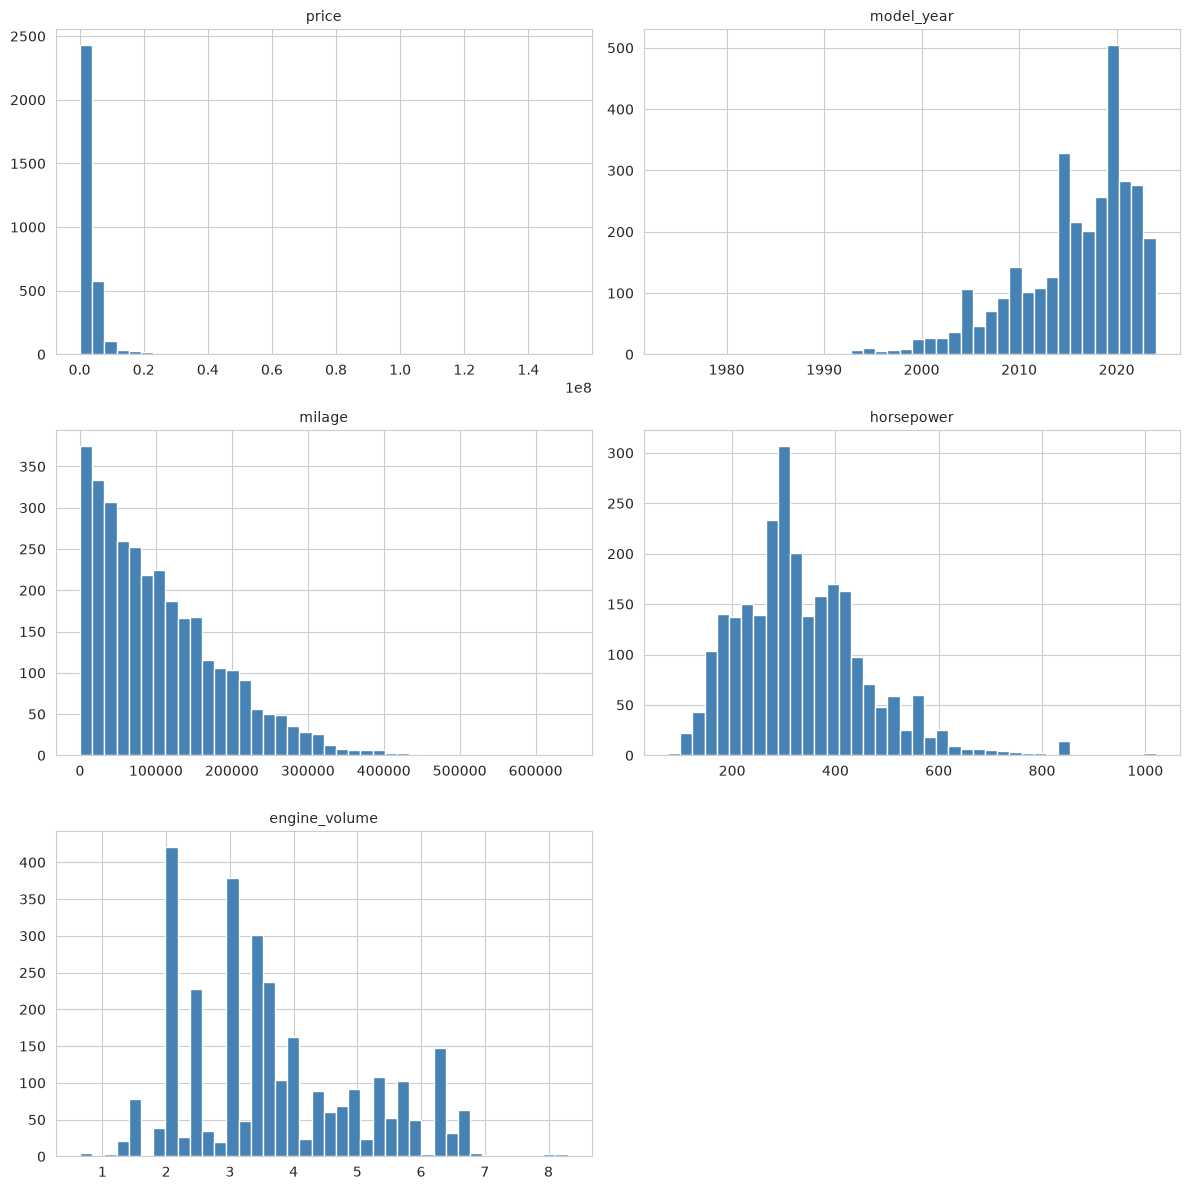

In [15]:
numeric_cols = ['price', 'model_year', 'milage', 'horsepower', 'engine_volume']

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df_clean[col].hist(
        bins=40,
        ax=axes[i],
        color='steelblue',
        edgecolor='white'
    )
    axes[i].set_title(col, fontsize=10)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

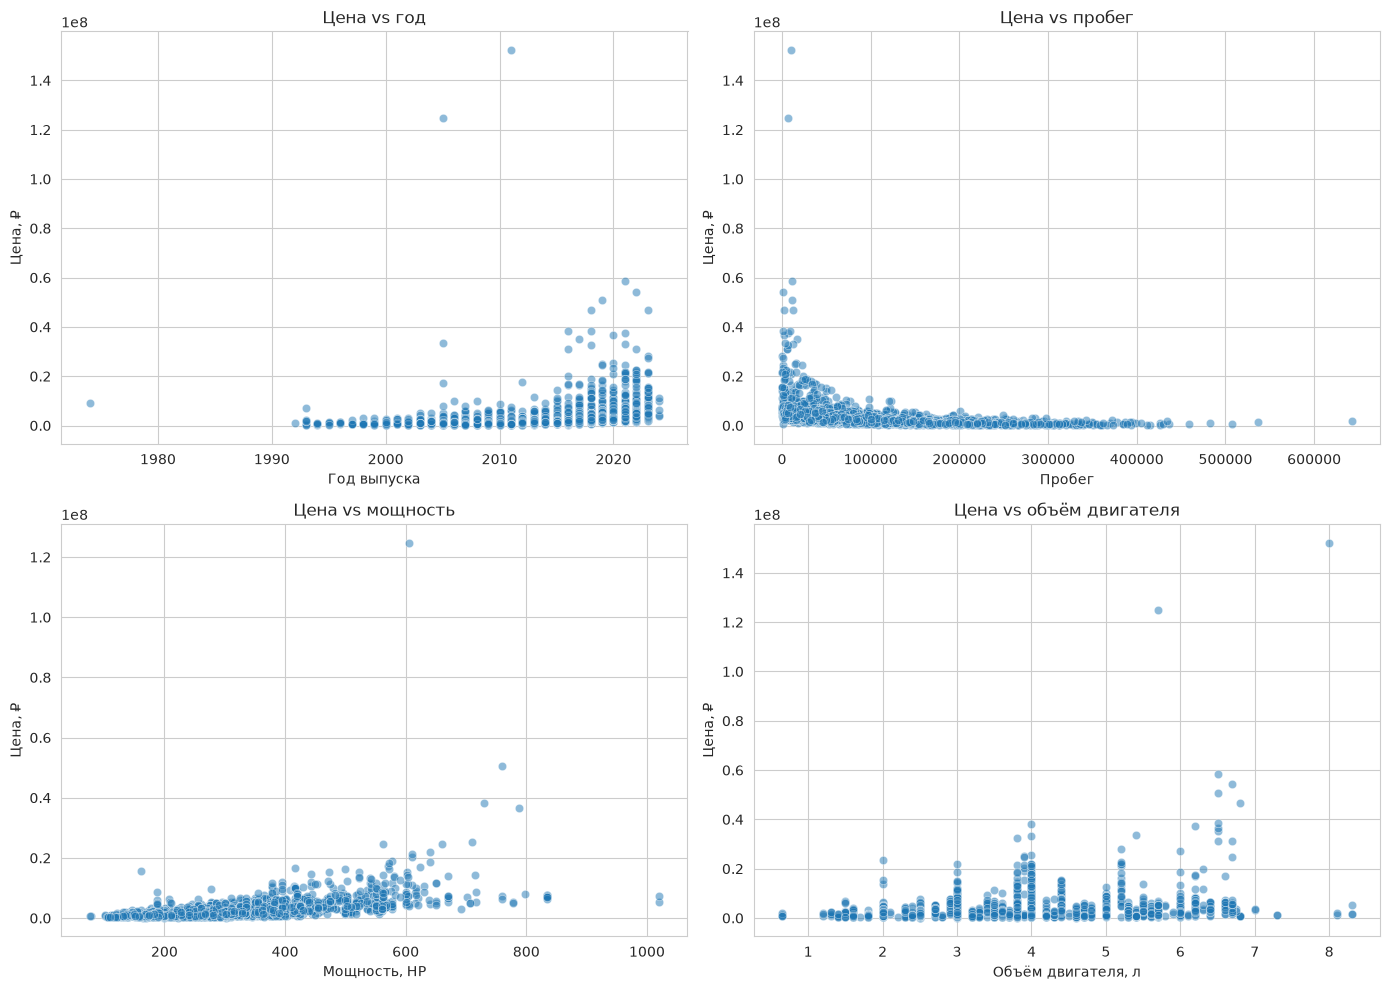

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df_clean, x='model_year', y='price', ax=axes[0, 0], alpha=0.5)
axes[0, 0].set_title('Цена vs год')
axes[0, 0].set_xlabel('Год выпуска')
axes[0, 0].set_ylabel('Цена, ₽')

sns.scatterplot(data=df_clean, x='milage', y='price', ax=axes[0, 1], alpha=0.5)
axes[0, 1].set_title('Цена vs пробег')
axes[0, 1].set_xlabel('Пробег')
axes[0, 1].set_ylabel('Цена, ₽')

sns.scatterplot(data=df_clean, x='horsepower', y='price', ax=axes[1, 0], alpha=0.5)
axes[1, 0].set_title('Цена vs мощность')
axes[1, 0].set_xlabel('Мощность, HP')
axes[1, 0].set_ylabel('Цена, ₽')

sns.scatterplot(data=df_clean, x='engine_volume', y='price', ax=axes[1, 1], alpha=0.5)
axes[1, 1].set_title('Цена vs объём двигателя')
axes[1, 1].set_xlabel('Объём двигателя, л')
axes[1, 1].set_ylabel('Цена, ₽')

plt.tight_layout()
plt.show()

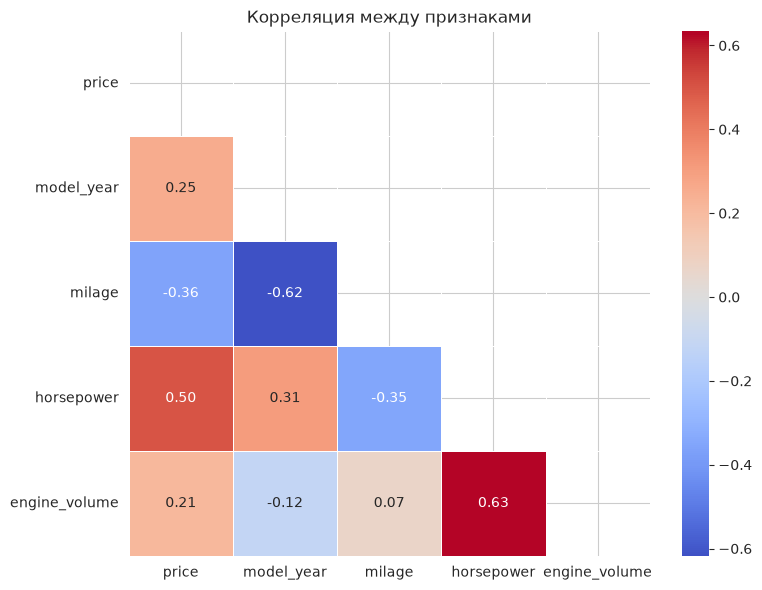

In [17]:
plt.figure(figsize=(8, 6))
numeric_cols = ['price', 'model_year', 'milage', 'horsepower', 'engine_volume']
corr = df_clean[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()


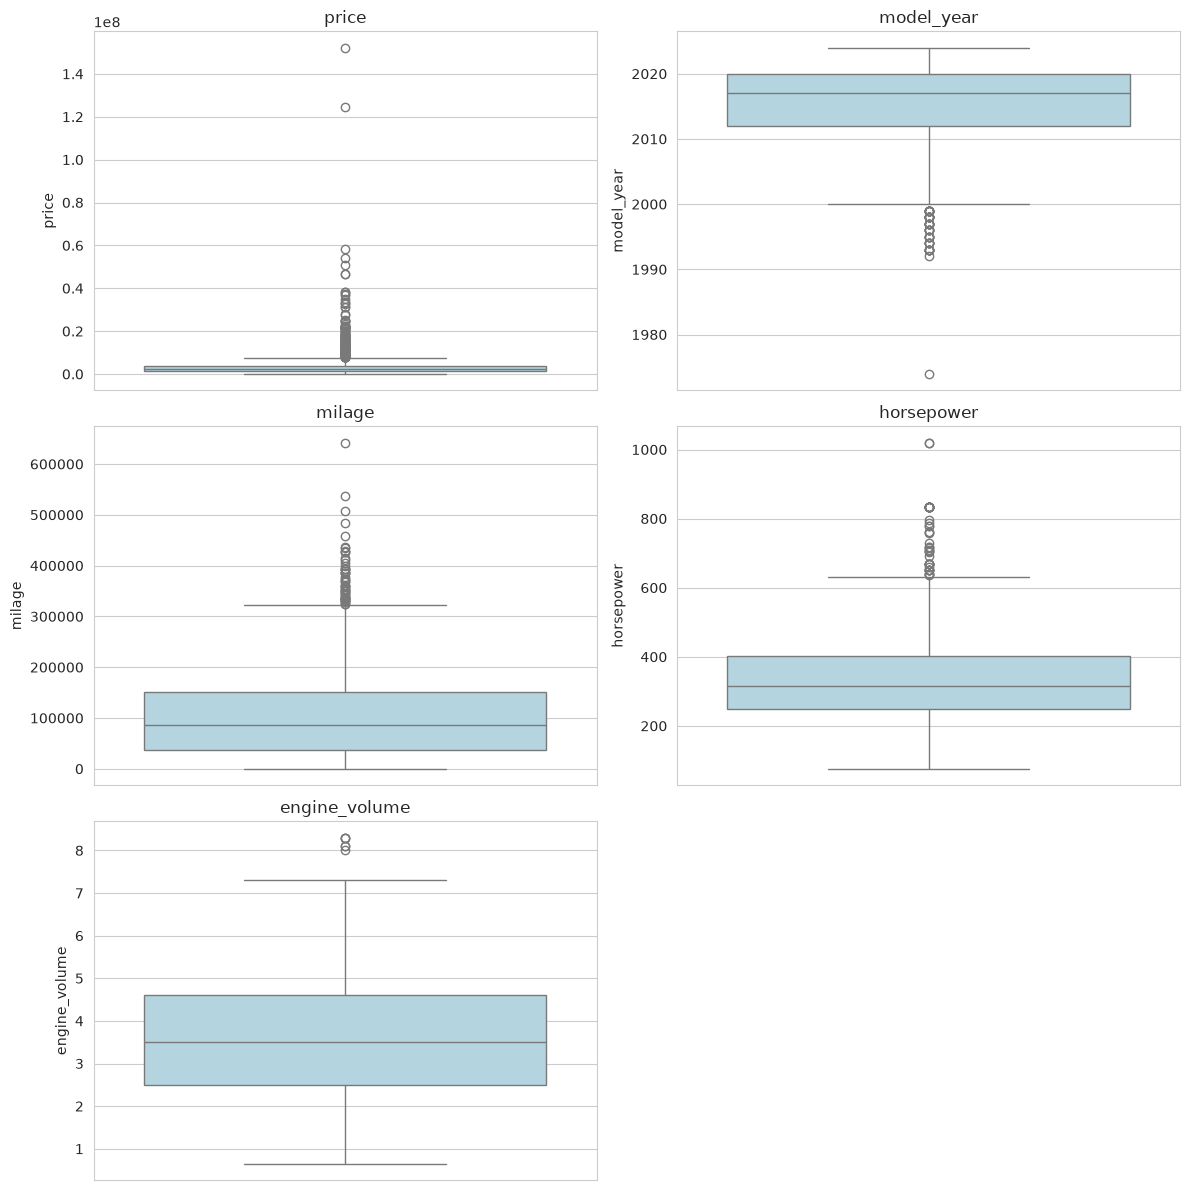

In [ ]:
numeric_cols = ['price', 'model_year', 'milage', 'horsepower', 'engine_volume']

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(
        y=df_clean[col],
        ax=axes[i],
        color='lightblue'
    )
    axes[i].set_title(col)

axes[-1].axis('off')

plt.tight_layout()
plt.show()

In [19]:
cat_cols = [
    'brand',
    'fuel_type',
    'transmission',
    'accident',
    'clean_title'
]

for col in cat_cols:
    print(f'\n{col}')

    display(
        df_clean.groupby(col)['price']
        .agg(['count', 'mean', 'median'])
        .sort_values('median', ascending=False)
    )


brand


,count,mean,median
brand,,,
Bugatti,1,1.522361e+08,1.522361e+08
Rolls-Royce,7,3.226925e+07,3.120810e+07
Lamborghini,21,2.324955e+07,2.028710e+07
Ferrari,11,1.922722e+07,1.988985e+07
McLaren,5,1.561841e+07,1.403760e+07
Bentley,23,1.113755e+07,8.817390e+06
Lucid,3,7.956433e+06,7.724970e+06
Rivian,15,7.248201e+06,7.295805e+06
Aston,9,8.989021e+06,6.242400e+06



fuel_type


,count,mean,median
fuel_type,,,
Electric,134,4.368645e+06,3757144.50
Diesel,89,3.938372e+06,3636041.94
Plug-In Hybrid,26,3.790388e+06,3588989.85
Hybrid,156,3.986281e+06,3550286.97
Gasoline,2653,3.456476e+06,2340821.97
E85 Flex Fuel,109,1.729498e+06,1466964.00
–,38,2.858307e+06,1267987.50
not supported,2,1.092420e+06,1092420.00



transmission


,count,mean,median
transmission,,,
7-Speed,1,5.851860e+07,5.851860e+07
8-SPEED A/T,1,2.262800e+07,2.262800e+07
"Automatic, 8-Spd Dual-Clutch",1,1.864137e+07,1.864137e+07
Manual,2,1.722497e+07,1.722497e+07
8-Speed Automatic with Auto-Shift,7,1.519242e+07,1.700664e+07
7-Speed Manual,2,1.653842e+07,1.653842e+07
7-Speed Automatic with Auto-Shift,20,2.216269e+07,1.618732e+07
9-Speed Automatic with Auto-Shift,1,1.122852e+07,1.122852e+07
"Manual, 6-Spd",2,9.827878e+06,9.827878e+06



accident


,count,mean,median
accident,,,
None reported,2318,3.953430e+06,2809080.0
No info,89,3.740541e+06,2563285.5
At least 1 accident or damage reported,800,2.035890e+06,1638630.0



clean_title


,count,mean,median
clean_title,,,
No,482,4.808018e+06,3355172.955
Yes,2725,3.232369e+06,2262870.000


In [20]:
df_clean = df_clean.drop(
    columns=['engine', 'ext_col', 'int_col', 'model']
)


# Выводы после графиков
1) Год выпуска и пробег заметно связаны между собой, но корреляция далеко не равна 1, поэтому автоматически удалять один из признаков не буду.
2) Из числовых признаков мощность двигателя выглядит одним из наиболее связанных с ценой признаков, поэтому оставляю ее для обучения.
3) В цене есть несколько очень дорогих автомобилей. Это реальные значения, поэтому строки удалять или обрезать по квантилю не буду. Вместо этого дальше логарифмирую целевую переменную, чтобы снизить влияние длинного хвоста распределения.
4) Выбросы в остальных признаках также не удаляю автоматически: для машин это могут быть реальные редкие характеристики. Обработку пропусков и масштабирование делаю внутри Pipeline, чтобы статистики считались только на обучающих фолдах.
5) По категориальным признакам особенно заметно влияние бренда: у премиальных марок медианная цена значительно выше. При этом у некоторых редких брендов объектов очень мало, поэтому делать выводы о силе отдельной категории только по средней цене нельзя.


# Создаем, обучаем и проверяем разные модели на 80% данных

In [21]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression

numeric_cols = ['model_year', 'milage', 'horsepower', 'engine_volume']
categorical_cols = ['brand', 'fuel_type', 'transmission', 'accident', 'clean_title']

X_dev = df_clean.drop(columns='price')
y_dev = np.log1p(df_clean['price'])

preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=21
)

scores = cross_validate(
    linear_pipeline,
    X_dev,
    y_dev,
    cv=cv,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    }
)

print('Linear Regression')
print('CV R²:', scores['test_r2'].mean())
print('CV R² std:', scores['test_r2'].std())
print('CV MAE:', -scores['test_mae'].mean())
print('CV RMSE:', -scores['test_rmse'].mean())


Linear Regression
CV R²: 0.8225314899961477
CV R² std: 0.019950743230799414
CV MAE: 0.25056048293130784
CV RMSE: 0.35563003608200155


In [ ]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import RandomizedSearchCV, cross_validate, KFold
from scipy.stats import loguniform

lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(max_iter=20000))
])

param_distributions = {
    'model__alpha': loguniform(1e-4, 1e1)
}

inner_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=21,
 )

lasso_search = RandomizedSearchCV(
    lasso_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=inner_cv,
    scoring='r2',
    random_state=21,
    
 )

scores = cross_validate(
    lasso_search,
    X_dev,
    y_dev,
    cv=cv,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    },
    
 )

print('Lasso')
print('CV R²:', scores['test_r2'].mean())
print('CV R² std:', scores['test_r2'].std())
print('CV MAE:', -scores['test_mae'].mean())
print('CV RMSE:', -scores['test_rmse'].mean())


Lasso
CV R²: 0.8209596025618768
CV R² std: 0.021817780100545883
CV MAE: 0.2501193322990769
CV RMSE: 0.3571263682659534


Lasso не улучшил результат относительно обычной линейной регрессии: средний R² снизился с 0.8225 до 0.8210, а RMSE немного вырос с 0.3556 до 0.3571. Разница небольшая, но преимуществ L1-регуляризации здесь не видно. Поэтому отдельно проверяю, даст ли пользу использование L1 только для отбора признаков перед обычной линейной регрессией.


In [23]:
from sklearn.feature_selection import SelectFromModel

lasso_ols_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('selector', SelectFromModel(
        Lasso(alpha=1e-3, max_iter=100000),
        threshold='median'
    )),
    ('model', LinearRegression())
])

# Более мягкая регуляризация, чтобы не происходило "No features were selected"
param_distributions = {
    'selector__estimator__alpha': loguniform(1e-6, 1e-2)
}

lasso_ols_search = RandomizedSearchCV(
    lasso_ols_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=inner_cv,
    scoring='r2',
    random_state=21
)

scores = cross_validate(
    lasso_ols_search,
    X_dev,
    y_dev,
    cv=cv,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    }
)

print('L1 selection + LinearRegression')
print('CV R²:', scores['test_r2'].mean())
print('CV R² std:', scores['test_r2'].std())
print('CV MAE:', -scores['test_mae'].mean())
print('CV RMSE:', -scores['test_rmse'].mean())

L1 selection + LinearRegression
CV R²: 0.8225314899961477
CV R² std: 0.019950743230799414
CV MAE: 0.25056048293130784
CV RMSE: 0.35563003608200155


Отбор признаков через L1 тоже не улучшил результат: метрики полностью совпали с обычной линейной регрессией — R² ≈ 0.8225 и RMSE ≈ 0.3556. То есть в этой задаче такой отбор не дал дополнительной пользы. Дальше оставляю все признаки и проверяю L2-регуляризацию.


In [24]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

# Значения alpha уменьшены, т.к. целевая логарифмирована
param_distributions = {
    'model__alpha': loguniform(1e-6, 1e2)
}

ridge_search = RandomizedSearchCV(
    ridge_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=inner_cv,
    scoring='r2',
    random_state=21,
    
 )

ridge_scores = cross_validate(
    ridge_search,
    X_dev,
    y_dev,
    cv=cv,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    },
    
 )

print('Ridge (L2)')
print('CV R²:', ridge_scores['test_r2'].mean())
print('CV R² std:', ridge_scores['test_r2'].std())
print('CV MAE:', -ridge_scores['test_mae'].mean())
print('CV RMSE:', -ridge_scores['test_rmse'].mean())


Ridge (L2)
CV R²: 0.8232519174114724
CV R² std: 0.02040454346102133
CV MAE: 0.2501696693506217
CV RMSE: 0.3548974837654244


Ridge дал небольшой прирост относительно обычной линейной регрессии: средний R² вырос примерно с 0.8225 до 0.8233, а RMSE снизился с 0.3556 до 0.3549. Разница совсем небольшая, но среди линейных моделей это лучший результат. Дальше проверяю SGDRegressor.


In [25]:
from sklearn.linear_model import SGDRegressor

sgd_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SGDRegressor(
        max_iter=200000,
        tol=1e-4,
        learning_rate='adaptive',
        eta0=0.01,
        random_state=21
    ))
])

param_distributions = {
    'model__eta0': loguniform(1e-4, 1e-1),
    'model__alpha': loguniform(1e-8, 1e-4)
}

sgd_search = RandomizedSearchCV(
    sgd_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=inner_cv,
    scoring='r2',
    random_state=21
)

scores = cross_validate(
    sgd_search,
    X_dev,
    y_dev,
    cv=cv,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    }
)

print('SGDRegressor')
print('CV R²:', scores['test_r2'].mean())
print('CV R² std:', scores['test_r2'].std())
print('CV MAE:', -scores['test_mae'].mean())
print('CV RMSE:', -scores['test_rmse'].mean())

SGDRegressor
CV R²: 0.8190718803380939
CV R² std: 0.02213383618031944
CV MAE: 0.25152917322330304
CV RMSE: 0.359016907494884


SGDRegressor оказался немного хуже остальных линейных моделей: R² ≈ 0.8191, RMSE ≈ 0.3590. В целом все линейные варианты дают очень близкое качество, поэтому похоже, что ограничение уже не столько в способе регуляризации или оптимизации, сколько в самой линейной форме зависимости. Поэтому добавляю нелинейную модель — Random Forest — и сравниваю ее по той же кросс-валидации.


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        random_state=21,
        
    ))
])

param_distributions = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [None, 5, 10, 15, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__max_features': ['sqrt', 0.5, 1.0]
}

rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=30,
    cv=inner_cv,
    scoring='r2',
    random_state=21,
    
)

rf_scores = cross_validate(
    rf_search,
    X_dev,
    y_dev,
    cv=cv,
    scoring={
        'r2': 'r2',
        'mae': 'neg_mean_absolute_error',
        'rmse': 'neg_root_mean_squared_error'
    },
    
)

print('Random Forest')
print('CV R²:', rf_scores['test_r2'].mean())
print('CV R² std:', rf_scores['test_r2'].std())
print('CV MAE:', -rf_scores['test_mae'].mean())
print('CV RMSE:', -rf_scores['test_rmse'].mean())

if rf_scores['test_r2'].mean() > ridge_scores['test_r2'].mean():
    best_search = rf_search
    best_model_name = 'Random Forest'
else:
    best_search = ridge_search
    best_model_name = 'Ridge'

print('Лучшая модель по CV:', best_model_name)


Random Forest
CV R²: 0.8627686661016339
CV R² std: 0.005184051248809662
CV MAE: 0.21770317656679583
CV RMSE: 0.31362216582852165
Лучшая модель по CV: Random Forest


In [28]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

df_test_clean = df_test_raw.copy()

df_test_clean['fuel_type'] = df_test_clean['fuel_type'].fillna('Electric')
df_test_clean['clean_title'] = df_test_clean['clean_title'].fillna('No')
df_test_clean['accident'] = df_test_clean['accident'].fillna('No info')

df_test_clean['price'] = pd.to_numeric(
    df_test_clean['price'].str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)
df_test_clean['price'] = df_test_clean['price'] * usd_to_rub

df_test_clean['milage'] = pd.to_numeric(
    df_test_clean['milage'].str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)
df_test_clean['milage'] = df_test_clean['milage'] * mi_to_km

df_test_clean['horsepower'] = pd.to_numeric(
    df_test_clean['engine']
        .astype(str)
        .str.extract(r'(\d+(?:\.\d+)?)\s*HP', expand=False),
    errors='coerce'
)

df_test_clean['engine_volume'] = pd.to_numeric(
    df_test_clean['engine']
        .astype(str)
        .str.extract(r'(\d+(?:\.\d+)?)\s*(?:L|Liter)', expand=False),
    errors='coerce'
)

df_test_clean = df_test_clean.drop(
    columns=['engine', 'ext_col', 'int_col', 'model']
)

X_test = df_test_clean.drop(columns='price')
y_test_log = np.log1p(df_test_clean['price'])

best_search.fit(X_dev, y_dev)
y_pred_log = best_search.predict(X_test)

rmsle = np.sqrt(np.mean((y_test_log - y_pred_log) ** 2))

print('Строк в исходном test:', len(df_test_raw))
print('Строк в test после преобразований:', len(X_test))
print(best_model_name)
print('Test R² (log-price):', r2_score(y_test_log, y_pred_log))
print('Test MAE (log-price):', mean_absolute_error(y_test_log, y_pred_log))
print('Test RMSE (log-price):', root_mean_squared_error(y_test_log, y_pred_log))
print('Test RMSLE:', rmsle)


Строк в исходном test: 802
Строк в test после преобразований: 802
Random Forest
Test R² (log-price): 0.8349222863610609
Test MAE (log-price): 0.22481468285285058
Test RMSE (log-price): 0.3472067501287909
Test RMSLE: 0.3472067501287909


# Итог после исправлений

1. Датасет разделяется на dev и test сразу после загрузки. Все EDA, решения по признакам и сравнение моделей выполняются только на dev-части.
2. Тестовая выборка не фильтруется, не обрезается по квантилям и не участвует в расчете статистик для preprocessing. В финальной ячейке число строк до и после преобразований одинаковое: 802, то есть ни один тестовый объект не был удален.
3. Строки с высокими ценами не удаляются. Целевая переменная переводится в лог-шкалу через `log1p`, чтобы снизить влияние длинного хвоста цены без удаления реальных дорогих автомобилей.
4. Imputer, StandardScaler и OneHotEncoder находятся внутри Pipeline, поэтому их параметры рассчитываются только на обучающих фолдах.
5. Все модели сравниваются по 5-fold кросс-валидации только на `X_dev` и `y_dev`. Random Forest проходит ту же схему оценки, что и линейные модели.
6. Линейные модели показали очень близкое качество. Лучший результат среди них у Ridge: CV R² ≈ 0.8233 и RMSE ≈ 0.3549. Lasso, L1-отбор и SGDRegressor улучшения не дали.
7. Random Forest заметно лучше линейных моделей: CV R² ≈ 0.8628, MAE ≈ 0.2177 и RMSE ≈ 0.3136. Поэтому финальной моделью выбирается Random Forest.
8. На полностью отложенном test Random Forest получил R² ≈ 0.8349, MAE ≈ 0.2248 и RMSE/RMSLE ≈ 0.3472 в лог-шкале.
9. Test-результат немного хуже среднего результата CV, что нормально для новых данных. При этом качество остается достаточно близким к кросс-валидации, поэтому сильного провала обобщающей способности после исправления утечки уже нет.
